# Day 4 — Attention & Transformers

## Arabic Sentiment Analysis using MARBERT

This notebook applies a pre-trained Transformer model, MARBERT, to Arabic sentiment classification.

The goal is to fine-tune MARBERT on an Arabic sentiment dataset and compare its performance with the LSTM model developed in Day 3.

In [1]:
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)



In [3]:
train_df = pd.read_json(
    "/content/arsentiment_train.jsonl",
    lines=True
)

val_df = pd.read_json(
    "/content/arsentiment_val.jsonl",
    lines=True
)

test_df = pd.read_json(
    "/content/arsentiment_test.jsonl",
    lines=True
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (14054, 3)
Validation: (3010, 3)
Test: (3013, 3)


##  Explore the Dataset

We inspect the dataset structure and preview sample Arabic text to understand the available columns and the sentiment labels.

In [4]:
print("Columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training samples:")
display(train_df.head())

Columns:
['id', 'text', 'sentiment']

First 5 training samples:


,id,text,sentiment
0,78975168,عاجل| وزارة الصحة: استشهاد اثنين بقصف صهيوني ش...,Negative
1,58359432,"وزارة الصحة: ""ارتقاء شاب متأثراً بإصابته برصاص...",Negative
2,70036334,بس مافهمت ليش كتبتو يتبع اكو جزء ثاني,Neutral
3,58364024,وزارة الصحة: يجب ارتداء الكمامات للوقاية من ا...,Neutral
4,50481889,شركات #الإنترنت فى #قطاع_غزة بتتصل فيه بتقله ...,Negative


In [5]:
print("Missing values in Train:")
print(train_df[["text", "sentiment"]].isnull().sum())

print("\nMissing values in Validation:")
print(val_df[["text", "sentiment"]].isnull().sum())

print("\nMissing values in Test:")
print(test_df[["text", "sentiment"]].isnull().sum())

Missing values in Train:
text         0
sentiment    0
dtype: int64

Missing values in Validation:
text         0
sentiment    1
dtype: int64

Missing values in Test:
text         0
sentiment    0
dtype: int64


## Inspect Missing Validation Label

The validation set contains one sample with a missing sentiment label.

We inspect this sample before removing it because a missing target label cannot be used for supervised model evaluation.

In [6]:
missing_val = val_df[
    val_df["sentiment"].isna()
]

print("Number of missing validation labels:", len(missing_val))

display(missing_val)

Number of missing validation labels: 1


,id,text,sentiment
1596,85152730,جامعة حائل تُطلق 25 برنامج أكاديمي جديد لمرحلت...,None


In [7]:
val_df = val_df.dropna(
    subset=["sentiment"]
).reset_index(drop=True)

print("Validation shape after cleaning:", val_df.shape)
print("Missing sentiment labels:", val_df["sentiment"].isna().sum())

Validation shape after cleaning: (3009, 3)
Missing sentiment labels: 0


##  Sentiment Distribution

We examine the distribution of sentiment classes across the training, validation, and test sets.

This helps us identify class imbalance before training the Transformer model.

In [8]:
print("Train distribution:")
print(train_df["sentiment"].value_counts())

print("\nValidation distribution:")
print(val_df["sentiment"].value_counts())

print("\nTest distribution:")
print(test_df["sentiment"].value_counts())

Train distribution:
sentiment
Negative    5541
Positive    5330
Neutral     2397
Complex      786
Name: count, dtype: int64

Validation distribution:
sentiment
Negative    1168
Positive    1132
Neutral      524
Complex      185
Name: count, dtype: int64

Test distribution:
sentiment
Negative    1166
Positive    1118
Neutral      545
Complex      184
Name: count, dtype: int64


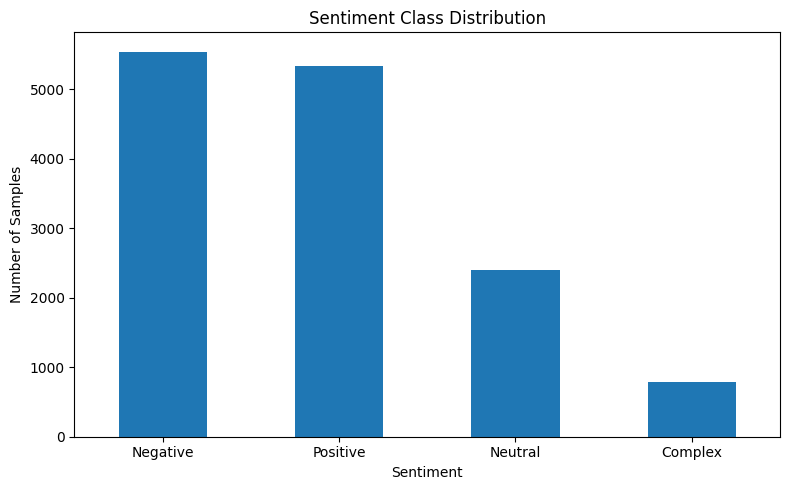

In [9]:
sentiment_counts = train_df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(
    kind="bar"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##  Text Cleaning

We apply light text preprocessing to remove noisy elements such as backslashes, separators, URLs, HTML tags, and emojis.

We avoid aggressive preprocessing such as stopword removal or stemming because these operations may remove useful linguistic information for sentiment classification.

In [10]:
import re

def clean_text(text):
    text = str(text)

    # Remove backslashes
    text = text.replace("\\", " ")

    # Remove separators
    text = text.replace("|", " ")

    # Replace URLs
    text = re.sub(
        r"http\S+|www\S+",
        " [URL] ",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Remove emojis and other symbols
    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001F5FF"
        "\U0001F600-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "\U00002700-\U000027BF"
        "\U00002600-\U000026FF"
        "]+",
        flags=re.UNICODE
    )

    text = emoji_pattern.sub(" ", text)

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [11]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Text cleaning completed successfully.")

Text cleaning completed successfully.


In [13]:
comparison = train_df[
    ["text", "clean_text"]
].head(10)

display(comparison)

,text,clean_text
0,عاجل| وزارة الصحة: استشهاد اثنين بقصف صهيوني ش...,عاجل وزارة الصحة: استشهاد اثنين بقصف صهيوني شم...
1,"وزارة الصحة: ""ارتقاء شاب متأثراً بإصابته برصاص...","وزارة الصحة: ""ارتقاء شاب متأثراً بإصابته برصاص..."
2,بس مافهمت ليش كتبتو يتبع اكو جزء ثاني,بس مافهمت ليش كتبتو يتبع اكو جزء ثاني
3,وزارة الصحة: يجب ارتداء الكمامات للوقاية من ا...,وزارة الصحة: يجب ارتداء الكمامات للوقاية من ال...
4,شركات #الإنترنت فى #قطاع_غزة بتتصل فيه بتقله ...,شركات #الإنترنت فى #قطاع_غزة بتتصل فيه بتقله ا...
5,النوم مش مريح بالمرة ؛(,النوم مش مريح بالمرة ؛(
6,الصيف هادا بالنسبة الي جيم و سباحة و كأس عالم ❤️,الصيف هادا بالنسبة الي جيم و سباحة و كأس عالم ️
7,الواحد مفلس من اول الشهر,الواحد مفلس من اول الشهر
8,سموه ميراس✨قريب لم اسم ميرا بليز✨🦋,سموه ميراس قريب لم اسم ميرا بليز
9,وزيرة الصحة: تسجيل 19 إصابة جديدة بفيروس كورون...,وزيرة الصحة: تسجيل 19 إصابة جديدة بفيروس كورون...


##  Encode Sentiment Labels

The sentiment labels are categorical text values. We convert them into numerical class indices so that they can be used by the MARBERT classification model.

The four classes are mapped as follows:

- Negative → 0
- Neutral → 1
- Positive → 2
- Complex → 3

In [14]:
label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "Complex": 3
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive",
    3: "Complex"
}

train_df["label"] = train_df["sentiment"].map(label2id)
val_df["label"] = val_df["sentiment"].map(label2id)
test_df["label"] = test_df["sentiment"].map(label2id)

print("Label mapping:")
print(label2id)

print("\nUnique train labels:")
print(sorted(train_df["label"].unique()))

Label mapping:
{'Negative': 0, 'Neutral': 1, 'Positive': 2, 'Complex': 3}

Unique train labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Prepare Data for Tokenization

We separate the cleaned text from the numerical sentiment labels.

The cleaned text will be passed to the MARBERT tokenizer, while the numerical labels will be used as classification targets.

In [15]:
X_train = train_df["clean_text"].tolist()
y_train = train_df["label"].astype(int).tolist()

X_val = val_df["clean_text"].tolist()
y_val = val_df["label"].astype(int).tolist()

X_test = test_df["clean_text"].tolist()
y_test = test_df["label"].astype(int).tolist()

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nUnique labels:", sorted(set(y_train)))

Training samples: 14054
Validation samples: 3009
Test samples: 3013

Unique labels: [0, 1, 2, 3]


##  Final Data Quality Check

Before tokenization, we perform a final check to ensure that there are no missing texts or labels and that all labels belong to the expected four sentiment classes.

In [16]:
print("Missing values:")
print("Train:", sum(pd.isna(X_train)), sum(pd.isna(y_train)))
print("Validation:", sum(pd.isna(X_val)), sum(pd.isna(y_val)))
print("Test:", sum(pd.isna(X_test)), sum(pd.isna(y_test)))

print("\nLabel validation:")
print("Train:", sorted(set(y_train)))
print("Validation:", sorted(set(y_val)))
print("Test:", sorted(set(y_test)))

Missing values:
Train: 0 0
Validation: 0 0
Test: 0 0

Label validation:
Train: [0, 1, 2, 3]
Validation: [0, 1, 2, 3]
Test: [0, 1, 2, 3]


##  Load MARBERT Tokenizer

We use the tokenizer associated with the pre-trained MARBERT model.

The tokenizer converts Arabic text into tokens and numerical input IDs that can be processed by the Transformer model.## 15. Load MARBERT Tokenizer

We use the tokenizer associated with the pre-trained MARBERT model.

The tokenizer converts Arabic text into tokens and numerical input IDs that can be processed by the Transformer model.

In [17]:
model_name = "UBC-NLP/MARBERT"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

print("MARBERT tokenizer loaded successfully.")

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MARBERT tokenizer loaded successfully.


##  Tokenize Arabic Text

We tokenize the cleaned Arabic text using the MARBERT tokenizer.

A maximum sequence length of 128 tokens is used. Longer texts are truncated, while shorter texts are padded to the required length.

In [18]:
MAX_LENGTH = 128

train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

val_encodings = tokenizer(
    X_val,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("Training samples:", len(train_encodings["input_ids"]))
print("Validation samples:", len(val_encodings["input_ids"]))
print("Test samples:", len(test_encodings["input_ids"]))

Training samples: 14054
Validation samples: 3009
Test samples: 3013


##  Inspect Tokenization

We inspect one tokenized sample to understand how MARBERT represents Arabic text using tokens, input IDs, and attention masks.

In [19]:
sample_text = X_train[0]

encoded_sample = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

tokens = tokenizer.convert_ids_to_tokens(
    encoded_sample["input_ids"][0]
)

print("Original text:")
print(sample_text)

print("\nFirst 20 tokens:")
print(tokens[:20])

print("\nInput IDs shape:")
print(encoded_sample["input_ids"].shape)

print("\nAttention mask shape:")
print(encoded_sample["attention_mask"].shape)


Original text:
عاجل وزارة الصحة: استشهاد اثنين بقصف صهيوني شمال قطاع غزة. #غزة_تحت_القصف

First 20 tokens:
['[CLS]', 'عاجل', 'وزارة', 'الصحة', ':', 'استشهاد', 'اثنين', 'بقصف', 'صهيوني', 'شمال', 'قطاع', 'غزة', '.', '[UNK]', 'غزة', '[UNK]', 'تحت', '[UNK]', 'القصف', '[SEP]']

Input IDs shape:
torch.Size([1, 128])

Attention mask shape:
torch.Size([1, 128])


## Load Pre-trained MARBERT

We load the pre-trained MARBERT model and adapt its classification head for the four Arabic sentiment classes.

MARBERT provides contextual Arabic representations that can capture relationships between words based on their surrounding context.

In [20]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("MARBERT model loaded successfully.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

MARBERT model loaded successfully.


In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


##  Create PyTorch Dataset

We create a custom PyTorch Dataset to organize the tokenized text and sentiment labels.

The labels are converted to `torch.long`, which is required by CrossEntropyLoss for multi-class classification.

In [22]:
from torch.utils.data import Dataset

class ArabicSentimentDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(
                val[idx],
                dtype=torch.long
            )
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

##  Create Train, Validation, and Test Datasets

We create separate PyTorch datasets for training, validation, and testing.

The training set is used to fine-tune MARBERT, the validation set is used to monitor performance during training, and the test set is reserved for the final evaluation.

In [23]:
train_dataset = ArabicSentimentDataset(
    train_encodings,
    y_train
)

val_dataset = ArabicSentimentDataset(
    val_encodings,
    y_val
)

test_dataset = ArabicSentimentDataset(
    test_encodings,
    y_test
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 14054
Validation dataset: 3009
Test dataset: 3013


In [24]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 879
Validation batches: 189
Test batches: 189


##  Verify Label Data Type

Before training, we verify that the sentiment labels are valid integer class indices.

PyTorch's CrossEntropyLoss requires the target labels to use the `torch.long` data type.

In [25]:
sample = train_dataset[0]

print("Label:", sample["labels"])
print("Label dtype:", sample["labels"].dtype)

print("\nValidation labels:")
print(sorted(set(y_val)))

print("\nTest labels:")
print(sorted(set(y_test)))

Label: tensor(0)
Label dtype: torch.int64

Validation labels:
[0, 1, 2, 3]

Test labels:
[0, 1, 2, 3]


##  Training Configuration

We fine-tune the pre-trained MARBERT model for Arabic sentiment classification.

The model is trained for a maximum of 20 epochs using the AdamW optimizer with a learning rate of 2e-5.

Macro F1-score is used as the main evaluation metric because the sentiment classes are imbalanced.

Early stopping will be used to stop training when validation performance no longer improves.

In [26]:
from torch.optim import AdamW

EPOCHS = 20
LEARNING_RATE = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Epochs: 20
Learning rate: 2e-05


##  Training Function

The training function fine-tunes MARBERT for one epoch.

For each batch, the model performs a forward pass, calculates the classification loss, computes gradients through backpropagation, and updates its parameters using the AdamW optimizer.

A progress bar is included to monitor the training progress and running loss.

In [27]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

def train_one_epoch(model, data_loader, optimizer, device):

    model.train()

    total_loss = 0
    all_predictions = []
    all_labels = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=True
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_loss = total_loss / len(data_loader)

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return avg_loss, macro_f1

In [28]:
def evaluate(model, data_loader, device):

    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(
            data_loader,
            desc="Validation",
            leave=True
        )

        for batch in progress_bar:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_predictions.extend(
                predictions.detach().cpu().numpy()
            )

            all_labels.extend(
                labels.detach().cpu().numpy()
            )

    avg_loss = total_loss / len(data_loader)

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return avg_loss, macro_f1

##  Fine-Tuning MARBERT

We fine-tune MARBERT on the Arabic sentiment training set for a maximum of 20 epochs.

After each epoch, the model is evaluated on the validation set. The model with the highest Validation Macro F1-score is saved as the best model.

Early stopping with a patience of 3 epochs is used to reduce overfitting and unnecessary training.

In [29]:
best_val_f1 = 0.0
best_model_state = None

train_losses = []
val_losses = []

train_f1_scores = []
val_f1_scores = []

patience = 3
patience_counter = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("=" * 50)

    # Training
    train_loss, train_f1 = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    # Validation
    val_loss, val_f1 = evaluate(
        model,
        val_loader,
        device
    )

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    print(f"\nTrain Loss:      {train_loss:.4f}")
    print(f"Train Macro F1:  {train_f1:.4f}")
    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Macro F1:    {val_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_marbert_model.pt"
        )

        patience_counter = 0

        print("✓ Best model saved.")

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{patience})"
        )

    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered.")
        break

print("\nTraining completed.")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")


Epoch 1/20


Training:   0%|          | 0/879 [00:00<?, ?it/s]

Validation:   0%|          | 0/189 [00:00<?, ?it/s]


Train Loss:      0.5874
Train Macro F1:  0.5999
Val Loss:        0.5345
Val Macro F1:    0.6225
✓ Best model saved.

Epoch 2/20


Training:   0%|          | 0/879 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/189 [00:00<?, ?it/s]


Train Loss:      0.0646
Train Macro F1:  0.9589
Val Loss:        0.9642
Val Macro F1:    0.6667
No improvement (2/3)

Epoch 6/20


Training:   0%|          | 0/879 [00:00<?, ?it/s]

Validation:   0%|          | 0/189 [00:00<?, ?it/s]


Train Loss:      0.0548
Train Macro F1:  0.9645
Val Loss:        1.0297
Val Macro F1:    0.6369
No improvement (3/3)

Early stopping triggered.

Training completed.
Best Validation Macro F1: 0.6776


##  Restore the Best MARBERT Model

The best model is the checkpoint with the highest Validation Macro F1-score.

Since the highest Validation Macro F1 was achieved at Epoch 3, we restore the saved best model before performing the final evaluation on the test set.

In [30]:
# Restore the best model
model.load_state_dict(best_model_state)

print("Best MARBERT model restored successfully.")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")

Best MARBERT model restored successfully.
Best Validation Macro F1: 0.6776


##  Final Test Evaluation

After restoring the best model based on Validation Macro F1, we evaluate it on the unseen test set.

We report Accuracy, Precision, Recall, and Macro F1 to measure the overall classification performance.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for batch in tqdm(
        test_loader,
        desc="Testing"
    ):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            labels.cpu().numpy()
        )


# Calculate metrics
test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

test_precision = precision_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

test_recall = recall_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)

test_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    average="macro"
)


print("MARBERT Test Results")
print("=" * 40)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"Macro F1:  {test_f1:.4f}")

Testing:   0%|          | 0/189 [00:00<?, ?it/s]

MARBERT Test Results
Accuracy:  0.7896
Precision: 0.6792
Recall:    0.6850
Macro F1:  0.6812


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=[
            id2label[0],
            id2label[1],
            id2label[2],
            id2label[3]
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     0.8602    0.8019    0.8300      1166
     Neutral     0.7729    0.7743    0.7736       545
    Positive     0.8336    0.8649    0.8490      1118
     Complex     0.2500    0.2989    0.2723       184

    accuracy                         0.7896      3013
   macro avg     0.6792    0.6850    0.6812      3013
weighted avg     0.7973    0.7896    0.7928      3013



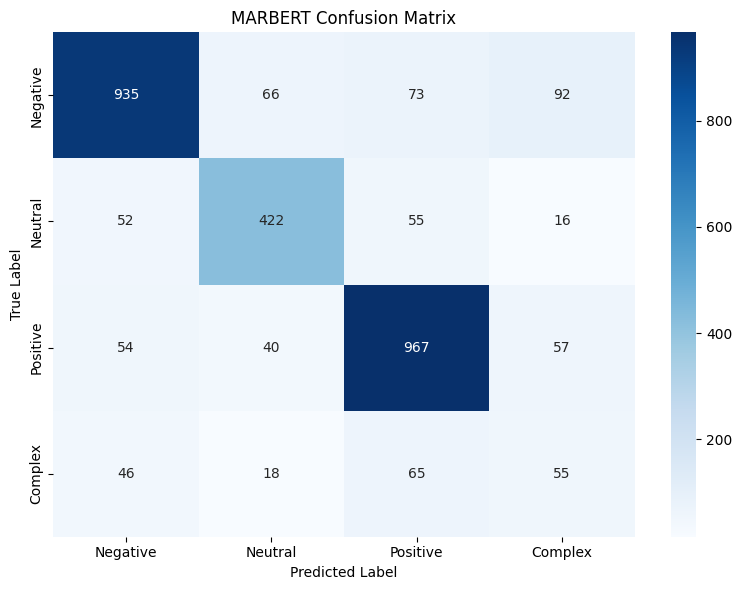

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        id2label[0],
        id2label[1],
        id2label[2],
        id2label[3]
    ],
    yticklabels=[
        id2label[0],
        id2label[1],
        id2label[2],
        id2label[3]
    ]
)

plt.title("MARBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()